SKILLNEXIS - WEEK 1 DATA ANALYSIS

Dataset loaded successfully!
Rows: 51290
Columns: 24

1. DATA CLEANING

Duplicate records before cleaning: 0
Duplicate records after cleaning: 0

Missing values before cleaning:
Postal Code    41296
dtype: int64

Missing values after cleaning:
No missing values remain.

2. DESCRIPTIVE STATISTICS

Total Revenue : $12,642,501.91
Mean Sales    : $246.49
Median Sales  : $85.05
Mode Sales    : $12.96
Variance      : $237,719.98

3. REGION-WISE SALES PIVOT TABLE
                          Sales
Region                         
Western Europe     1.731930e+06
Central America    1.223101e+06
Oceania            1.100185e+06
Southeastern Asia  8.844232e+05
Southern Asia      8.665727e+05
Eastern Asia       8.550594e+05
Western US         7.254578e+05
Eastern US         6.787812e+05
Northern Europe    6.367792e+05
South America      6.172237e+05
Southern Europe    6.085940e+05
Central US         5.012399e+05
Southern US        3.917219e+05
Caribbean          3.242

C:\Users\SAINATH\AppData\Local\Temp\ipykernel_21128\3030398078.py:74: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


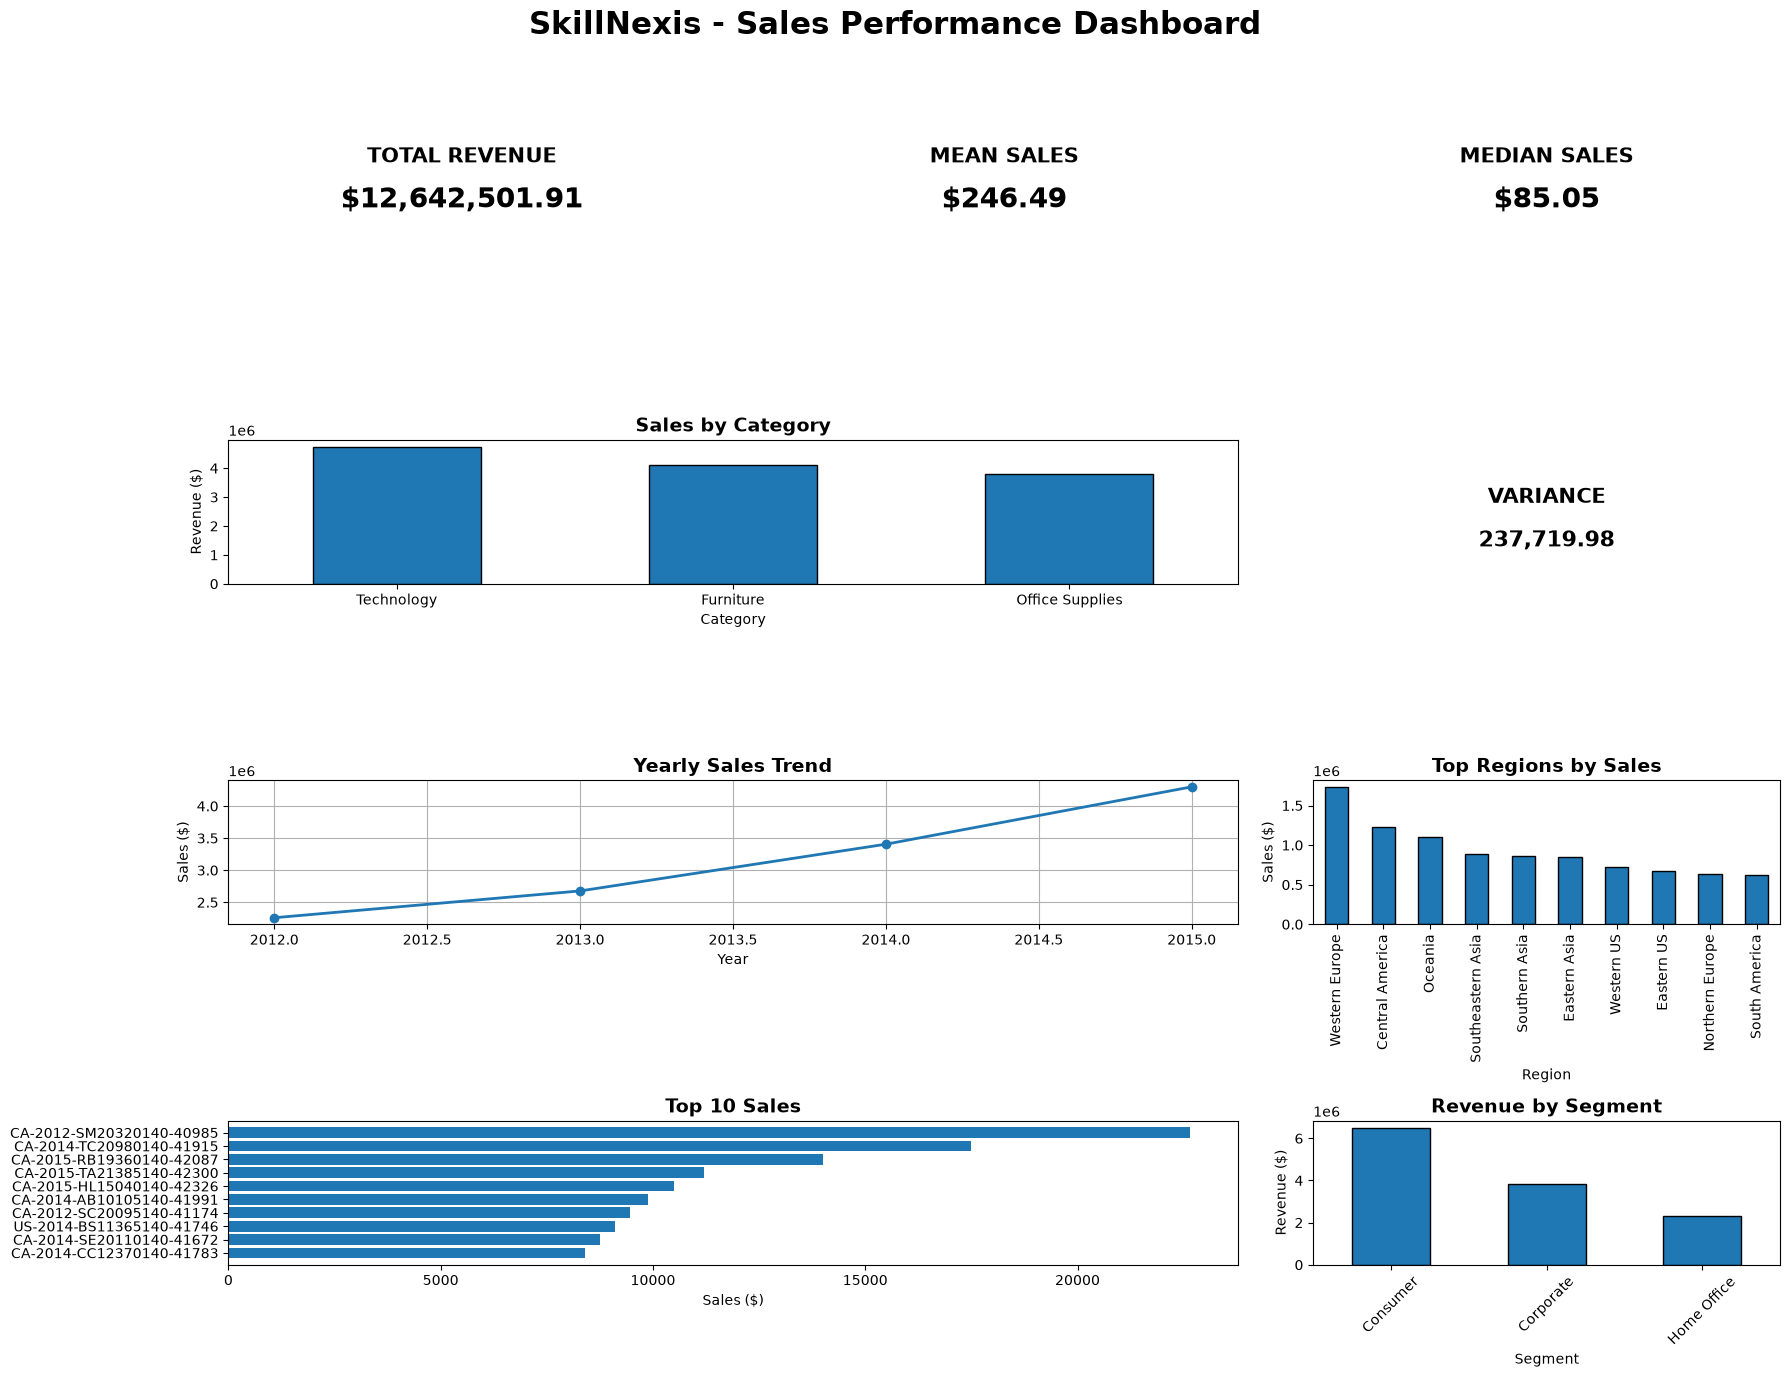


WEEK 1 COMPLETED SUCCESSFULLY

Completed:

[✓] Removed duplicate records
[✓] Handled missing values
[✓] Region-wise sales Pivot Table
[✓] Mean
[✓] Median
[✓] Mode
[✓] Variance
[✓] Top 10 Sales
[✓] Category-wise Revenue
[✓] Yearly Sales Trend
[✓] Revenue by Segment
[✓] Total Revenue
[✓] Sales Performance Dashboard

Generated files:

- cleaned_sales_data.csv
- region_wise_sales.csv
- category_wise_revenue.csv
- yearly_sales_trend.csv
- revenue_by_segment.csv
- top_10_sales.csv
- sales_performance_dashboard.png



In [6]:
# ============================================================
# SKILLNEXIS - DATA SCIENCE WITH PYTHON INTERNSHIP
# WEEK 1 - EXCEL & DATA FUNDAMENTALS
# SALES DATA ANALYSIS PROJECT
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

file_path = "global_superstore_2016.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="Orders"
)

print("=" * 70)
print("SKILLNEXIS - WEEK 1 DATA ANALYSIS")
print("=" * 70)

print("\nDataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))


# ------------------------------------------------------------
# 2. DATA CLEANING
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("1. DATA CLEANING")
print("=" * 70)

# Check duplicates
duplicate_count = df.duplicated().sum()

print("\nDuplicate records before cleaning:", duplicate_count)

# Remove duplicates
df = df.drop_duplicates()

print("Duplicate records after cleaning:", df.duplicated().sum())


# Check missing values
print("\nMissing values before cleaning:")

missing_before = df.isnull().sum()

print(
    missing_before[missing_before > 0]
)


# Handle numeric missing values
numeric_columns = df.select_dtypes(
    include="number"
).columns

for column in numeric_columns:

    if df[column].isnull().sum() > 0:

        df[column] = df[column].fillna(
            df[column].median()
        )


# Handle categorical missing values
categorical_columns = df.select_dtypes(
    include="object"
).columns

for column in categorical_columns:

    if df[column].isnull().sum() > 0:

        mode_value = df[column].mode()

        if len(mode_value) > 0:

            df[column] = df[column].fillna(
                mode_value.iloc[0]
            )

        else:

            df[column] = df[column].fillna(
                "Unknown"
            )


print("\nMissing values after cleaning:")

missing_after = df.isnull().sum()

remaining_missing = missing_after[
    missing_after > 0
]

if len(remaining_missing) == 0:

    print("No missing values remain.")

else:

    print(remaining_missing)


# ------------------------------------------------------------
# 3. CREATE YEAR COLUMN
# ------------------------------------------------------------

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    errors="coerce"
)

df["Year"] = df["Order Date"].dt.year


# ------------------------------------------------------------
# 4. DESCRIPTIVE STATISTICS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("2. DESCRIPTIVE STATISTICS")
print("=" * 70)

sales = df["Sales"]

total_revenue = sales.sum()

mean_sales = sales.mean()

median_sales = sales.median()

mode_sales = sales.mode().iloc[0]

variance_sales = sales.var()


print(f"\nTotal Revenue : ${total_revenue:,.2f}")
print(f"Mean Sales    : ${mean_sales:,.2f}")
print(f"Median Sales  : ${median_sales:,.2f}")
print(f"Mode Sales    : ${mode_sales:,.2f}")
print(f"Variance      : ${variance_sales:,.2f}")


# ------------------------------------------------------------
# 5. REGION-WISE PIVOT TABLE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("3. REGION-WISE SALES PIVOT TABLE")
print("=" * 70)

region_pivot = pd.pivot_table(
    df,
    values="Sales",
    index="Region",
    aggfunc="sum"
)

region_pivot = region_pivot.sort_values(
    by="Sales",
    ascending=False
)

print(region_pivot)


# ------------------------------------------------------------
# 6. CATEGORY-WISE PIVOT TABLE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("4. CATEGORY-WISE REVENUE")
print("=" * 70)

category_pivot = pd.pivot_table(
    df,
    values="Sales",
    index="Category",
    aggfunc="sum"
)

category_pivot = category_pivot.sort_values(
    by="Sales",
    ascending=False
)

print(category_pivot)


# ------------------------------------------------------------
# 7. YEARLY SALES PIVOT TABLE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("5. YEARLY SALES TREND")
print("=" * 70)

yearly_pivot = pd.pivot_table(
    df,
    values="Sales",
    index="Year",
    aggfunc="sum"
)

print(yearly_pivot)


# ------------------------------------------------------------
# 8. REVENUE BY SEGMENT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("6. REVENUE BY SEGMENT")
print("=" * 70)

segment_pivot = pd.pivot_table(
    df,
    values="Sales",
    index="Segment",
    aggfunc="sum"
)

segment_pivot = segment_pivot.sort_values(
    by="Sales",
    ascending=False
)

print(segment_pivot)


# ------------------------------------------------------------
# 9. TOP 10 SALES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("7. TOP 10 SALES")
print("=" * 70)

top_10 = df.nlargest(
    10,
    "Sales"
)

display_columns = []

for column in [
    "Order ID",
    "Customer Name",
    "Category",
    "Sales"
]:

    if column in df.columns:

        display_columns.append(column)


print(
    top_10[display_columns]
)


# ------------------------------------------------------------
# 10. SAVE ANALYSIS RESULTS
# ------------------------------------------------------------

region_pivot.to_csv(
    "region_wise_sales.csv"
)

category_pivot.to_csv(
    "category_wise_revenue.csv"
)

yearly_pivot.to_csv(
    "yearly_sales_trend.csv"
)

segment_pivot.to_csv(
    "revenue_by_segment.csv"
)

top_10[display_columns].to_csv(
    "top_10_sales.csv",
    index=False
)


# ============================================================
# 11. COMPLETE SALES DASHBOARD
# ============================================================

print("\nCreating dashboard...")

fig = plt.figure(
    figsize=(18, 14)
)

fig.suptitle(
    "SkillNexis - Sales Performance Dashboard",
    fontsize=22,
    fontweight="bold"
)


# ------------------------------------------------------------
# TOTAL REVENUE KPI
# ------------------------------------------------------------

ax1 = plt.subplot2grid(
    (4, 3),
    (0, 0)
)

ax1.axis("off")

ax1.text(
    0.5,
    0.60,
    "TOTAL REVENUE",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold"
)

ax1.text(
    0.5,
    0.30,
    f"${total_revenue:,.2f}",
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold"
)


# ------------------------------------------------------------
# MEAN SALES KPI
# ------------------------------------------------------------

ax2 = plt.subplot2grid(
    (4, 3),
    (0, 1)
)

ax2.axis("off")

ax2.text(
    0.5,
    0.60,
    "MEAN SALES",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold"
)

ax2.text(
    0.5,
    0.30,
    f"${mean_sales:,.2f}",
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold"
)


# ------------------------------------------------------------
# MEDIAN SALES KPI
# ------------------------------------------------------------

ax3 = plt.subplot2grid(
    (4, 3),
    (0, 2)
)

ax3.axis("off")

ax3.text(
    0.5,
    0.60,
    "MEDIAN SALES",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold"
)

ax3.text(
    0.5,
    0.30,
    f"${median_sales:,.2f}",
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold"
)


# ------------------------------------------------------------
# CATEGORY-WISE REVENUE
# ------------------------------------------------------------

ax4 = plt.subplot2grid(
    (4, 3),
    (1, 0),
    colspan=2
)

category_pivot["Sales"].plot(
    kind="bar",
    ax=ax4,
    edgecolor="black"
)

ax4.set_title(
    "Sales by Category",
    fontsize=14,
    fontweight="bold"
)

ax4.set_xlabel("Category")

ax4.set_ylabel("Revenue ($)")

ax4.tick_params(
    axis="x",
    rotation=0
)


# ------------------------------------------------------------
# VARIANCE
# ------------------------------------------------------------

ax5 = plt.subplot2grid(
    (4, 3),
    (1, 2)
)

ax5.axis("off")

ax5.text(
    0.5,
    0.60,
    "VARIANCE",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold"
)

ax5.text(
    0.5,
    0.30,
    f"{variance_sales:,.2f}",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)


# ------------------------------------------------------------
# YEARLY SALES TREND
# ------------------------------------------------------------

ax6 = plt.subplot2grid(
    (4, 3),
    (2, 0),
    colspan=2
)

yearly_pivot["Sales"].plot(
    kind="line",
    marker="o",
    linewidth=2,
    ax=ax6
)

ax6.set_title(
    "Yearly Sales Trend",
    fontsize=14,
    fontweight="bold"
)

ax6.set_xlabel("Year")

ax6.set_ylabel("Sales ($)")

ax6.grid(True)


# ------------------------------------------------------------
# REGION-WISE SALES
# ------------------------------------------------------------

ax7 = plt.subplot2grid(
    (4, 3),
    (2, 2)
)

region_pivot["Sales"].head(10).plot(
    kind="bar",
    ax=ax7,
    edgecolor="black"
)

ax7.set_title(
    "Top Regions by Sales",
    fontsize=14,
    fontweight="bold"
)

ax7.set_xlabel("Region")

ax7.set_ylabel("Sales ($)")

ax7.tick_params(
    axis="x",
    rotation=90
)


# ------------------------------------------------------------
# TOP 10 SALES
# ------------------------------------------------------------

ax8 = plt.subplot2grid(
    (4, 3),
    (3, 0),
    colspan=2
)

top_10_chart = top_10.sort_values(
    "Sales"
)

ax8.barh(
    range(len(top_10_chart)),
    top_10_chart["Sales"]
)

ax8.set_yticks(
    range(len(top_10_chart))
)

ax8.set_yticklabels(
    top_10_chart["Order ID"]
    if "Order ID" in top_10_chart.columns
    else range(1, 11)
)

ax8.set_title(
    "Top 10 Sales",
    fontsize=14,
    fontweight="bold"
)

ax8.set_xlabel("Sales ($)")


# ------------------------------------------------------------
# REVENUE BY SEGMENT
# ------------------------------------------------------------

ax9 = plt.subplot2grid(
    (4, 3),
    (3, 2)
)

segment_pivot["Sales"].plot(
    kind="bar",
    ax=ax9,
    edgecolor="black"
)

ax9.set_title(
    "Revenue by Segment",
    fontsize=14,
    fontweight="bold"
)

ax9.set_xlabel("Segment")

ax9.set_ylabel("Revenue ($)")

ax9.tick_params(
    axis="x",
    rotation=45
)


# ------------------------------------------------------------
# SAVE DASHBOARD
# ------------------------------------------------------------

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.savefig(
    "sales_performance_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 12. SAVE CLEANED DATA
# ------------------------------------------------------------

df.to_csv(
    "cleaned_sales_data.csv",
    index=False
)


# ------------------------------------------------------------
# FINAL MESSAGE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("WEEK 1 COMPLETED SUCCESSFULLY")
print("=" * 70)

print("""
Completed:

[✓] Removed duplicate records
[✓] Handled missing values
[✓] Region-wise sales Pivot Table
[✓] Mean
[✓] Median
[✓] Mode
[✓] Variance
[✓] Top 10 Sales
[✓] Category-wise Revenue
[✓] Yearly Sales Trend
[✓] Revenue by Segment
[✓] Total Revenue
[✓] Sales Performance Dashboard

Generated files:

- cleaned_sales_data.csv
- region_wise_sales.csv
- category_wise_revenue.csv
- yearly_sales_trend.csv
- revenue_by_segment.csv
- top_10_sales.csv
- sales_performance_dashboard.png
""")